In [4]:
import scqubits
import numpy as np
from scipy.optimize import minimize


import sys
sys.path.append('../')
from utils_models import *


In [150]:
EJ = 4
EC = 1
EL = 4/20

qubit_level = 70


def get_shift_accurate(ele,omega_i, omega_j, omega_r):
    return abs(ele)**2 / (omega_j-omega_i-omega_r) - abs(ele)**2 / (omega_i-omega_j-omega_r)


qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
evals = qbt.eigenvals(qubit_level)
elements = qbt.matrixelement_table('n_operator',evals_count = qubit_level)

def shift_diff(x):
    Er = x[0]

    shifts_from_one = [get_shift_accurate(elements[1,ql2],evals[ql2],evals[1],Er) for ql2 in range(qubit_level)] 
    shift_from_one = sum(shifts_from_one)
    shifts_from_two = [get_shift_accurate(elements[2,ql2],evals[ql2],evals[2],Er) for ql2 in range(qubit_level)] 
    shift_from_two = sum(shifts_from_two)
    return abs(shift_from_one-shift_from_two)

initial_guess = [4*2.8]

# Call the optimizer
result = minimize(shift_diff, initial_guess, method='Nelder-Mead')

print("Result:", result)
print("Optimal solution:", result.x)
print("Objective value:", result.fun)


Result:        message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 6.046336619679182e-07
             x: [ 1.147e+01]
           nit: 14
          nfev: 28
 final_simplex: (array([[ 1.147e+01],
                       [ 1.147e+01]]), array([ 6.046e-07,  1.132e-06]))
Optimal solution: [11.46660156]
Objective value: 6.046336619679182e-07


In [154]:
evals[-1]

421.33296792595


qubit 12 transition and differential stark at different oscillator level
qbt freq at osc 0:	0.04514773495931035
qbt freq at osc 1:	0.04515, 	diff to at osc ground -0.00000, 0.0023% diff
qbt freq at osc 2:	0.04515, 	diff to at osc ground -0.00000, 0.0049% diff
qbt freq at osc 3:	0.04514, 	diff to at osc ground -0.00000, 0.0079% diff
qbt freq at osc 4:	0.04514, 	diff to at osc ground -0.00001, 0.0113% diff
qbt freq at osc 5:	0.04514, 	diff to at osc ground -0.00001, 0.0150% diff
qbt freq at osc 6:	0.04514, 	diff to at osc ground -0.00001, 0.0191% diff
qbt freq at osc 7:	0.04514, 	diff to at osc ground -0.00001, 0.0236% diff
qbt freq at osc 8:	0.04513, 	diff to at osc ground -0.00001, 0.0285% diff
qbt freq at osc 9:	0.04513, 	diff to at osc ground -0.00002, 0.0337% diff
qbt freq at osc 10:	0.04513, 	diff to at osc ground -0.00002, 0.0394% diff
qbt freq at osc 11:	0.04513, 	diff to at osc ground -0.00002, 0.0454% diff
qbt freq at osc 12:	0.04512, 	diff to at osc ground -0.00002, 0.0518% d

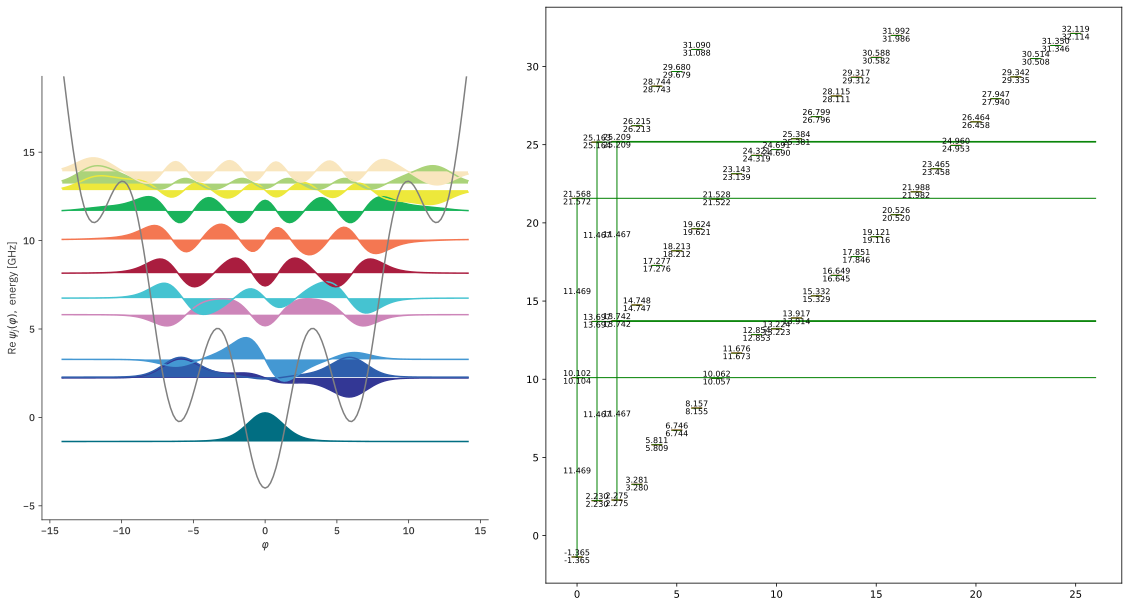

In [155]:

max_ol = 70
max_ql = 70
g = 0.2
system = FluxoniumOscillatorSystem(
    EJ = EJ,
    EC = EC,
    EL = EL,
    Er = result.x[0],
    g_strength = g,
    qubit_level = max_ql,
    osc_level = max_ol,
    # kappa = 0.004,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '1,2'
    )


energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
def print_stats():
    print(f"\nqubit 12 transition and differential stark at different oscillator level")
    print(f"qbt freq at osc {0}:\t{(dressed_ener(2,0)-dressed_ener(1,0))}")
    ground_freq = dressed_ener(2,0)-dressed_ener(1,0)
    for i in range(1,max_ol-1):
        freq = dressed_ener(2,i)-dressed_ener(1,i)
        print(f"qbt freq at osc {i}:\t{freq:.5f}, \tdiff to at osc ground {freq - ground_freq:.5f}, {abs(freq - ground_freq)/ground_freq*100:.4f}% diff")

    print(f"\noscillator freq at qubit level:\t0 \t 1 \t 2 \t 3:")
    print(f"oscillator transition 0-1: \t{dressed_ener(0,1)-dressed_ener(0,0):.5f}\t{dressed_ener(1,1)-dressed_ener(1,0):.5f}\t{dressed_ener(2,1)-dressed_ener(2,0):.5f}\t{dressed_ener(3,1)-dressed_ener(3,0):.5f}")
    for i in range(1,max_ol-1):
        print(f"oscillator transition {i}-{i+1}: \t{dressed_ener(0,i+1)-dressed_ener(0,i):.5f}\t{dressed_ener(1,i+1)-dressed_ener(1,i):.5f}\t{dressed_ener(2,i+1)-dressed_ener(2,i):.5f}\t{dressed_ener(3,i+1)-dressed_ener(3,i):.5f}  oscillator frequency coupled to qubit 0th state compared to 00-01 (non-linearity): {(dressed_ener(0,i+1)-dressed_ener(0,i))  -(dressed_ener(0,1)-dressed_ener(0,0))}")

    print(f"")
    print(f"10-11: {(dressed_ener(1,1)-dressed_ener(1,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(1,1)-dressed_ener(1,0)))}")
    print(f"20-21: {(dressed_ener(2,1)-dressed_ener(2,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
print_stats()
# plot_specturum(system.qbt, system.osc, system.hilbertspace,num_levels = 50)

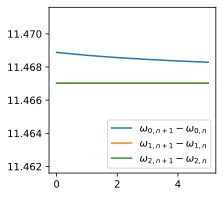

In [152]:
plt.figure(figsize = (3,3))
n_osc_lvls = 6
dressed_osc_frequencies = [[] for _ in range(3)]
for j in [0,1,2]:
    for i in range(0,max_ol-1):
        dressed_osc_frequencies[j].append(dressed_ener(j,i+1)-dressed_ener(j,i))
        
for j in [0,1,2]:
    plt.plot(list(range(max_ol-1))[:n_osc_lvls], dressed_osc_frequencies[j][:n_osc_lvls],label=rf'$\omega_{{{j},n+1}} - \omega_{{{j},n}}$')

plt.xticks(list(range(n_osc_lvls))[::2])
plt.ylim(result.x[0]-0.005, result.x[0]+0.005)
# plt.xticklabels([str(i) for i in range(n_osc_lvls)])
plt.legend(loc='lower right')

In [157]:

evals, evecs = system.hilbertspace.hamiltonian().eigenstates()
overlap_matrix = scqubits.utils.spectrum_utils.convert_evecs_to_ndarray(evecs)
def print_top_two_dressed_state(product_index):
    overlaps_with_product_state = np.abs(overlap_matrix[:, product_index])
    sorted_indices = np.argsort(overlaps_with_product_state)[::-1]
    sorted_overlaps = overlaps_with_product_state[sorted_indices]
    print(list(sorted_indices)[:2])
    print(list(sorted_overlaps)[:2])

print(f"\t\tqubit 0\t\t\tqubit 1 \t\t qubit 2")

print(f"osc lvl\t\tdressed-overlap^2\tdressed-overlap^2\tdressed-overlap^2")
for i in range(40):
    product_index_q0 = 0 * system.osc.truncated_dim + i
    product_index_q1 = 1 * system.osc.truncated_dim + i
    product_index_q2 = 2 * system.osc.truncated_dim + i

    overlaps_with_product_state_q0 = np.abs(overlap_matrix[:, product_index_q0])
    sorted_indices_q0 = np.argsort(overlaps_with_product_state_q0)[::-1]
    sorted_overlaps_q0 = overlaps_with_product_state_q0[sorted_indices_q0]

    overlaps_with_product_state_q1 = np.abs(overlap_matrix[:, product_index_q1])
    sorted_indices_q1 = np.argsort(overlaps_with_product_state_q1)[::-1]
    sorted_overlaps_q1 = overlaps_with_product_state_q1[sorted_indices_q1]
    
    overlaps_with_product_state_q2 = np.abs(overlap_matrix[:, product_index_q2])
    sorted_indices_q2 = np.argsort(overlaps_with_product_state_q2)[::-1]
    sorted_overlaps_q2 = overlaps_with_product_state_q2[sorted_indices_q2]

    print(f"ol-{i}:\t\t{list(sorted_indices_q0)[0]}-{list(sorted_overlaps_q0)[0]**2:.3f} \t\t{list(sorted_indices_q1)[0]}-{list(sorted_overlaps_q1)[0]**2:.3f} \t\t{list(sorted_indices_q2)[0]}-{list(sorted_overlaps_q2)[0]**2:.3f}")

		qubit 0			qubit 1 		 qubit 2
osc lvl		dressed-overlap^2	dressed-overlap^2	dressed-overlap^2
ol-0:		0-1.000 		1-1.000 		2-1.000
ol-1:		8-0.962 		12-1.000 		13-0.999
ol-2:		25-0.933 		32-1.000 		33-0.999
ol-3:		51-0.910 		61-0.999 		62-0.998
ol-4:		86-0.892 		99-0.999 		100-0.997
ol-5:		130-0.877 		146-0.999 		147-0.996
ol-6:		184-0.864 		202-0.999 		203-0.996
ol-7:		246-0.853 		267-0.999 		268-0.995
ol-8:		316-0.844 		337-0.998 		338-0.994
ol-9:		386-0.836 		407-0.998 		408-0.993
ol-10:		456-0.828 		477-0.998 		478-0.993
ol-11:		526-0.822 		547-0.998 		548-0.992
ol-12:		596-0.816 		617-0.998 		618-0.991
ol-13:		666-0.811 		687-0.997 		688-0.990
ol-14:		736-0.807 		757-0.997 		758-0.990
ol-15:		806-0.803 		827-0.997 		828-0.989
ol-16:		876-0.799 		897-0.997 		898-0.988
ol-17:		946-0.795 		967-0.997 		968-0.987
ol-18:		1016-0.792 		1037-0.996 		1038-0.987
ol-19:		1086-0.789 		1107-0.996 		1108-0.986
ol-20:		1156-0.787 		1177-0.996 		1178-0.985
ol-21:		1226-0.784 		1247-0.996 		1248-0.98